In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import pickle
import plotly.express as px
import streamlit as st
import os


In [27]:
os.chdir('C:\\Users\\adima\\OneDrive\\Documents\\Cohort 128_ML_ Day 43\\Stremlit Deployment and PBI Dashboard\\')

In [28]:
car_data=pd.read_csv("car_data.csv")
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Invoice Price,Used/New Price,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,0,Aston Martin,DBX707,2024,Base,"$242,000",NaN,"$242,000",Large,SUV,V8,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,20 mpg
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$33,653","$35,800",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$35,533","$37,800",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$38,917","$41,400",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$37,037","$39,400",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,"$50,990",NaN,"$50,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,28 mpg
1606,6411,Nissan,Z,2023,Proto Spec,"$53,990",NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,28 mpg
1607,6412,Nissan,Z,2023,Proto Spec,"$53,990",NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,24 mpg
1608,6413,Nissan,Z,2023,Sport,"$40,990",NaN,"$40,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,24 mpg


In [29]:
np.unique(car_data['Trim'].fillna('0'))
len(np.unique(car_data['Trim'].fillna('0')))

373

In [30]:
len(np.unique(car_data['Make'].fillna('0')))

7

In [31]:
for column in car_data:
    unique_vals=np.unique(car_data[column].fillna('0'))
    num_vals=len(unique_vals)
    if num_vals < 12:
        print('the unique values of column {}:{}--{}'.format(column,num_vals,unique_vals))
    else:
        print('the unique values of column {}:{}'.format(column,num_vals))

the unique values of column index:1610
the unique values of column Make:7--['Aston Martin' 'Audi' 'BMW' 'Bentley' 'Ford' 'Mercedes-Benz' 'Nissan']
the unique values of column Model:150
the unique values of column Year:2--[2023 2024]
the unique values of column Trim:373
the unique values of column MSRP:1317
the unique values of column Invoice Price:944
the unique values of column Used/New Price:1317
the unique values of column Body Size:3--['Compact' 'Large' 'Midsize']
the unique values of column Body Style:12
the unique values of column Cylinders:10--['0' 'I3' 'I4' 'I5' 'I6' 'V10' 'V12' 'V6' 'V8' 'W12']
the unique values of column Engine Aspiration:6--['Electric Motor' 'Naturally Aspirated' 'Supercharged' 'Turbocharged'
 'Twin-Turbo' 'Twincharged']
the unique values of column Drivetrain:4--['4WD' 'AWD' 'FWD' 'RWD']
the unique values of column Transmission:2--['automatic' 'manual']
the unique values of column Horsepower:192
the unique values of column Torque:176
the unique values of col

In [32]:
print(car_data.isnull().sum())

index                     0
Make                      0
Model                     0
Year                      0
Trim                      0
MSRP                      0
Invoice Price           552
Used/New Price            0
Body Size                 0
Body Style                0
Cylinders               165
Engine Aspiration         0
Drivetrain                0
Transmission              0
Horsepower                5
Torque                   27
Highway Fuel Economy    424
dtype: int64


In [33]:
car_data.shape


(1610, 17)

In [34]:
car_data=car_data.drop(['Invoice Price','Cylinders','Highway Fuel Economy'],axis=1)
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque
0,0,Aston Martin,DBX707,2024,Base,"$242,000","$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,"$50,990","$50,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm
1606,6411,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm
1607,6412,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm
1608,6413,Nissan,Z,2023,Sport,"$40,990","$40,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm


In [35]:
car_data["Horsepower_No"]=car_data["Horsepower"].str[0:3].astype(float)
display(car_data["Horsepower_No"])

0       697.0
1       201.0
2       201.0
3       201.0
4       201.0
        ...  
1605    400.0
1606    400.0
1607    400.0
1608    400.0
1609    400.0
Name: Horsepower_No, Length: 1610, dtype: float64

In [36]:
display(car_data[car_data["Horsepower_No"].isna()])

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No
371,971,Ford,F-150 Lightning,2024,Flash,"$67,995","$67,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
372,972,Ford,F-150 Lightning,2024,Lariat,"$76,995","$76,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
373,973,Ford,F-150 Lightning,2024,Platinum,"$84,995","$84,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
374,974,Ford,F-150 Lightning,2024,Pro,"$54,995","$54,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN
375,975,Ford,F-150 Lightning,2024,XLT,"$62,995","$62,995",Large,Pickup Truck,Electric Motor,4WD,automatic,NaN,NaN,NaN


In [37]:
mean_HP=car_data["Horsepower_No"][car_data["Make"]=="Ford"].mean()
print(mean_HP)

333.2254428341385


In [38]:
car_data["Horsepower_No"]=car_data["Horsepower_No"].fillna(mean_HP)
car_data["Horsepower"]=car_data["Horsepower"].fillna(mean_HP)
display(car_data[car_data["Horsepower"].isna()])

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No


In [39]:
car_data["Torque_No"]=car_data["Torque"].str[0:3].astype(float)
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,"$242,000","$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,"$50,990","$50,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1606,6411,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1607,6412,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1608,6413,Nissan,Z,2023,Sport,"$40,990","$40,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0


In [40]:
mean_tor=car_data['Torque_No'][car_data['Make']=='Ford'].mean()
car_data['Torque_No']=car_data['Torque_No'].fillna(mean_tor)
car_data['Torque']=car_data['Torque'].fillna(mean_tor)

In [41]:
display(car_data[car_data['Torque_No'].isna()])

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No


In [42]:
display(car_data.isna().sum())

index                0
Make                 0
Model                0
Year                 0
Trim                 0
MSRP                 0
Used/New Price       0
Body Size            0
Body Style           0
Engine Aspiration    0
Drivetrain           0
Transmission         0
Horsepower           0
Torque               0
Horsepower_No        0
Torque_No            0
dtype: int64

In [43]:
print(car_data.dtypes)

index                  int64
Make                  object
Model                 object
Year                   int64
Trim                  object
MSRP                  object
Used/New Price        object
Body Size             object
Body Style            object
Engine Aspiration     object
Drivetrain            object
Transmission          object
Horsepower            object
Torque                object
Horsepower_No        float64
Torque_No            float64
dtype: object


In [44]:
display(car_data)
car_data['MSRP']=car_data['MSRP'].str.replace('$','')
car_data['MSRP']=car_data['MSRP'].str.replace(',','').astype(float)


,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,"$242,000","$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,"$50,990","$50,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1606,6411,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1607,6412,Nissan,Z,2023,Proto Spec,"$53,990","$53,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1608,6413,Nissan,Z,2023,Sport,"$40,990","$40,990",Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0


In [45]:
car_data['Used/New Price']=car_data['Used/New Price'].str.replace('$','')
car_data['Used/New Price']=car_data['Used/New Price'].str.replace(',','').astype(float)
display(car_data)

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Horsepower_No,Torque_No
0,0,Aston Martin,DBX707,2024,Base,242000.0,242000.0,Large,SUV,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,35800.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,37800.0,37800.0,Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,41400.0,Compact,Sedan,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,39400.0,Compact,Sedan,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,50990.0,50990.0,Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1606,6411,Nissan,Z,2023,Proto Spec,53990.0,53990.0,Compact,Coupe,Twin-Turbo,RWD,automatic,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1607,6412,Nissan,Z,2023,Proto Spec,53990.0,53990.0,Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0
1608,6413,Nissan,Z,2023,Sport,40990.0,40990.0,Compact,Coupe,Twin-Turbo,RWD,manual,400 hp @ 6400 rpm,350 ft-lbs. @ 1600 rpm,400.0,350.0


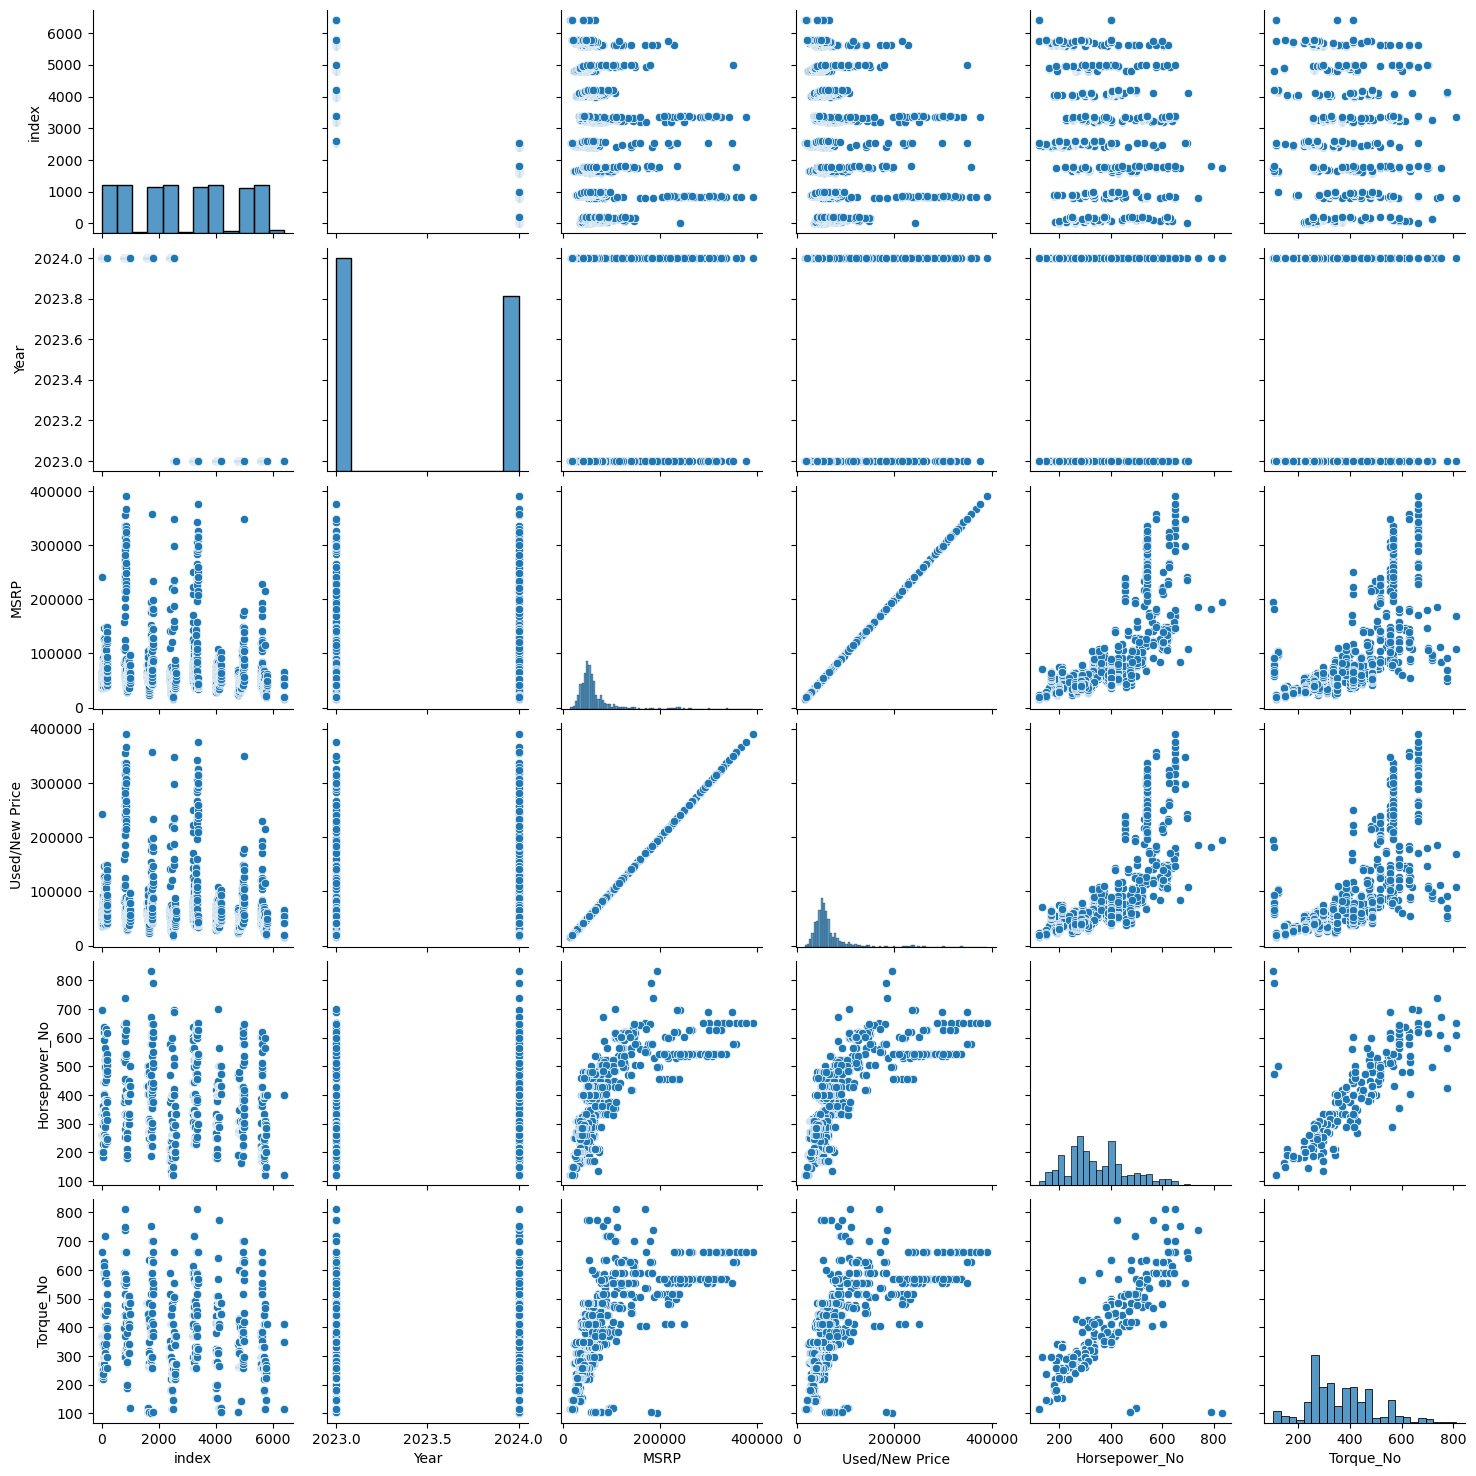

In [46]:
sns.pairplot(car_data)
plt.show()

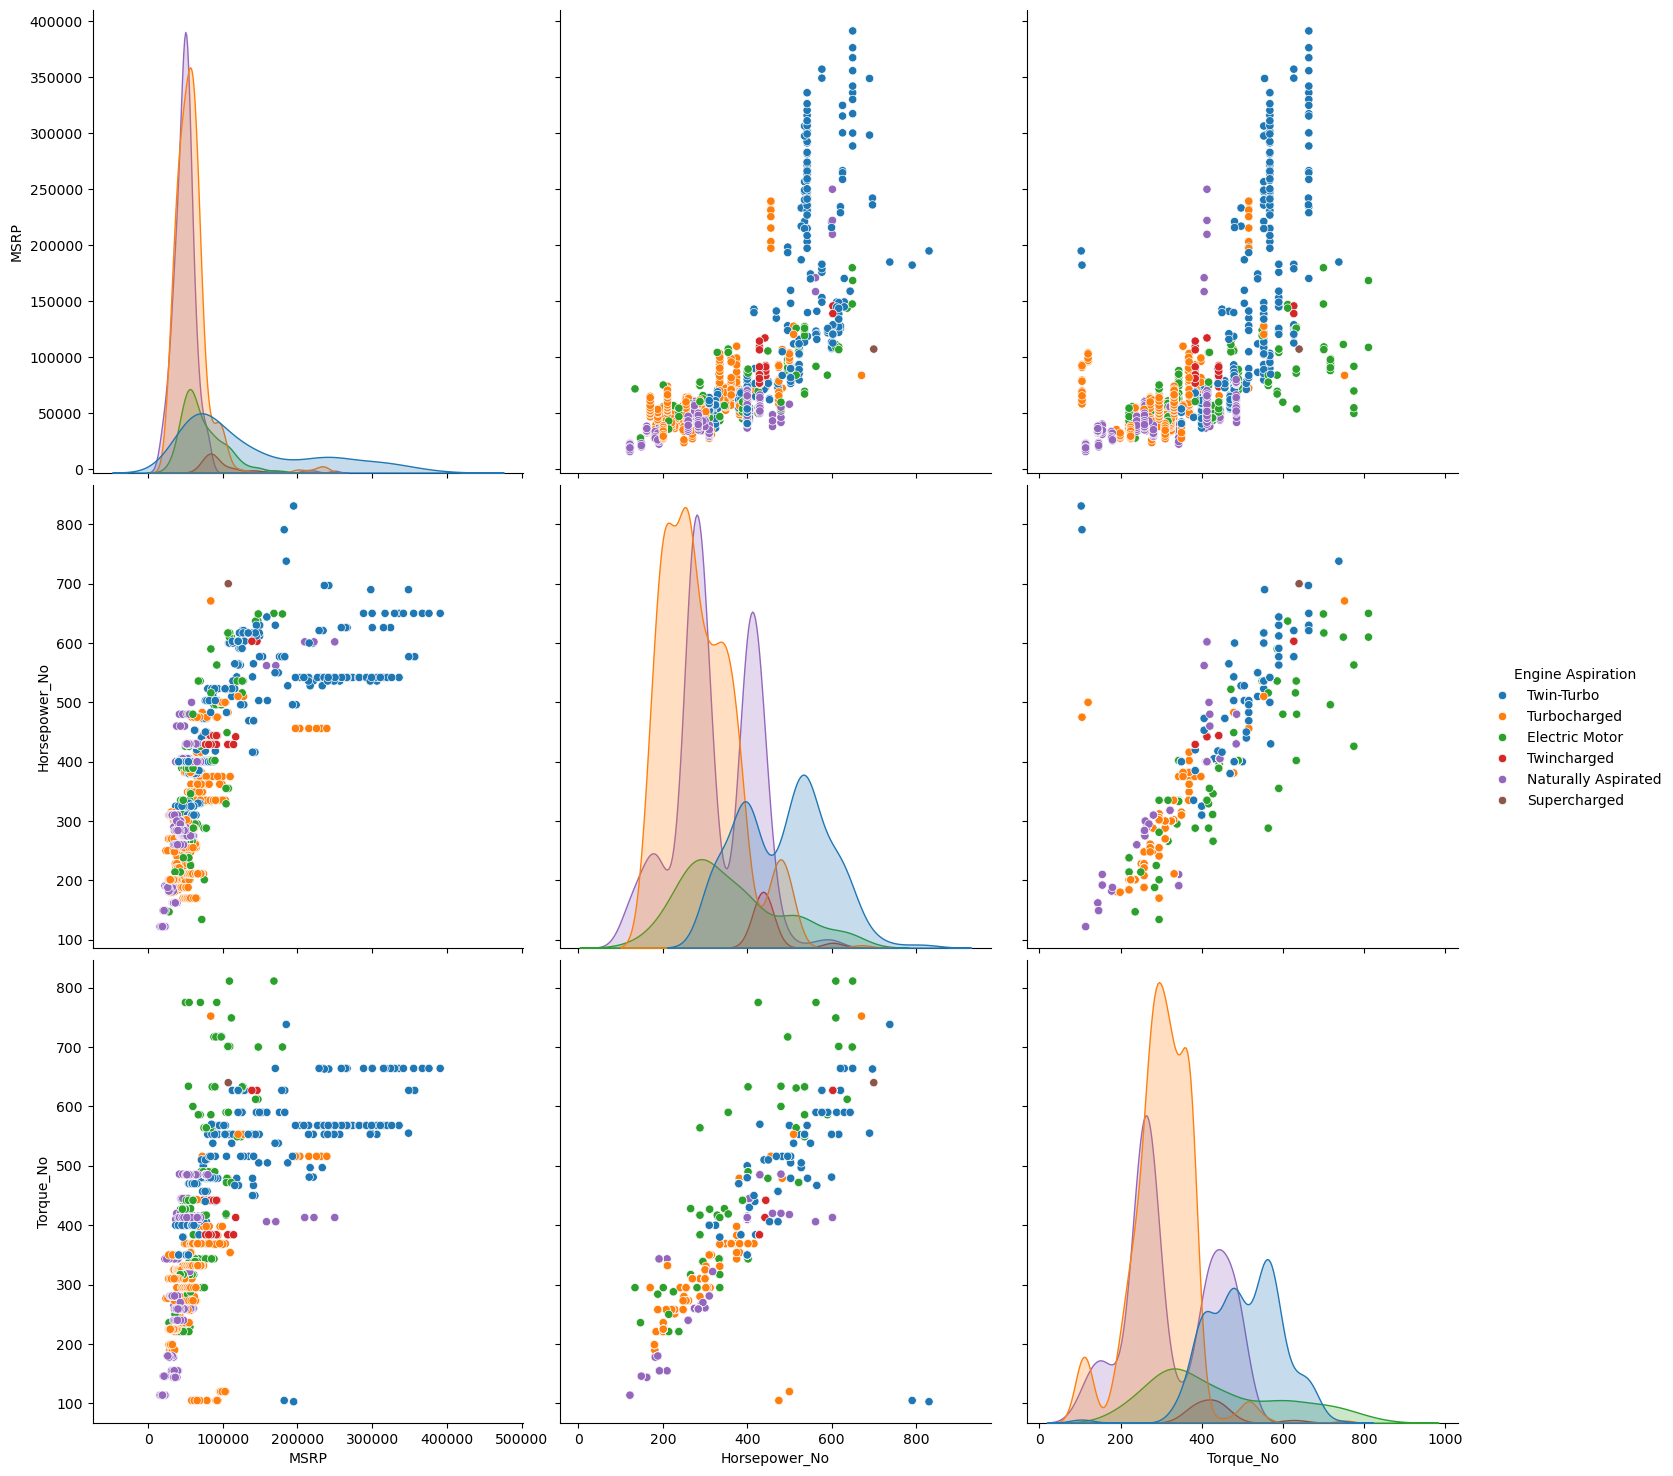

In [47]:
sns.pairplot(car_data[['MSRP','Horsepower_No','Torque_No','Engine Aspiration']],hue='Engine Aspiration',height=5)
plt.show()

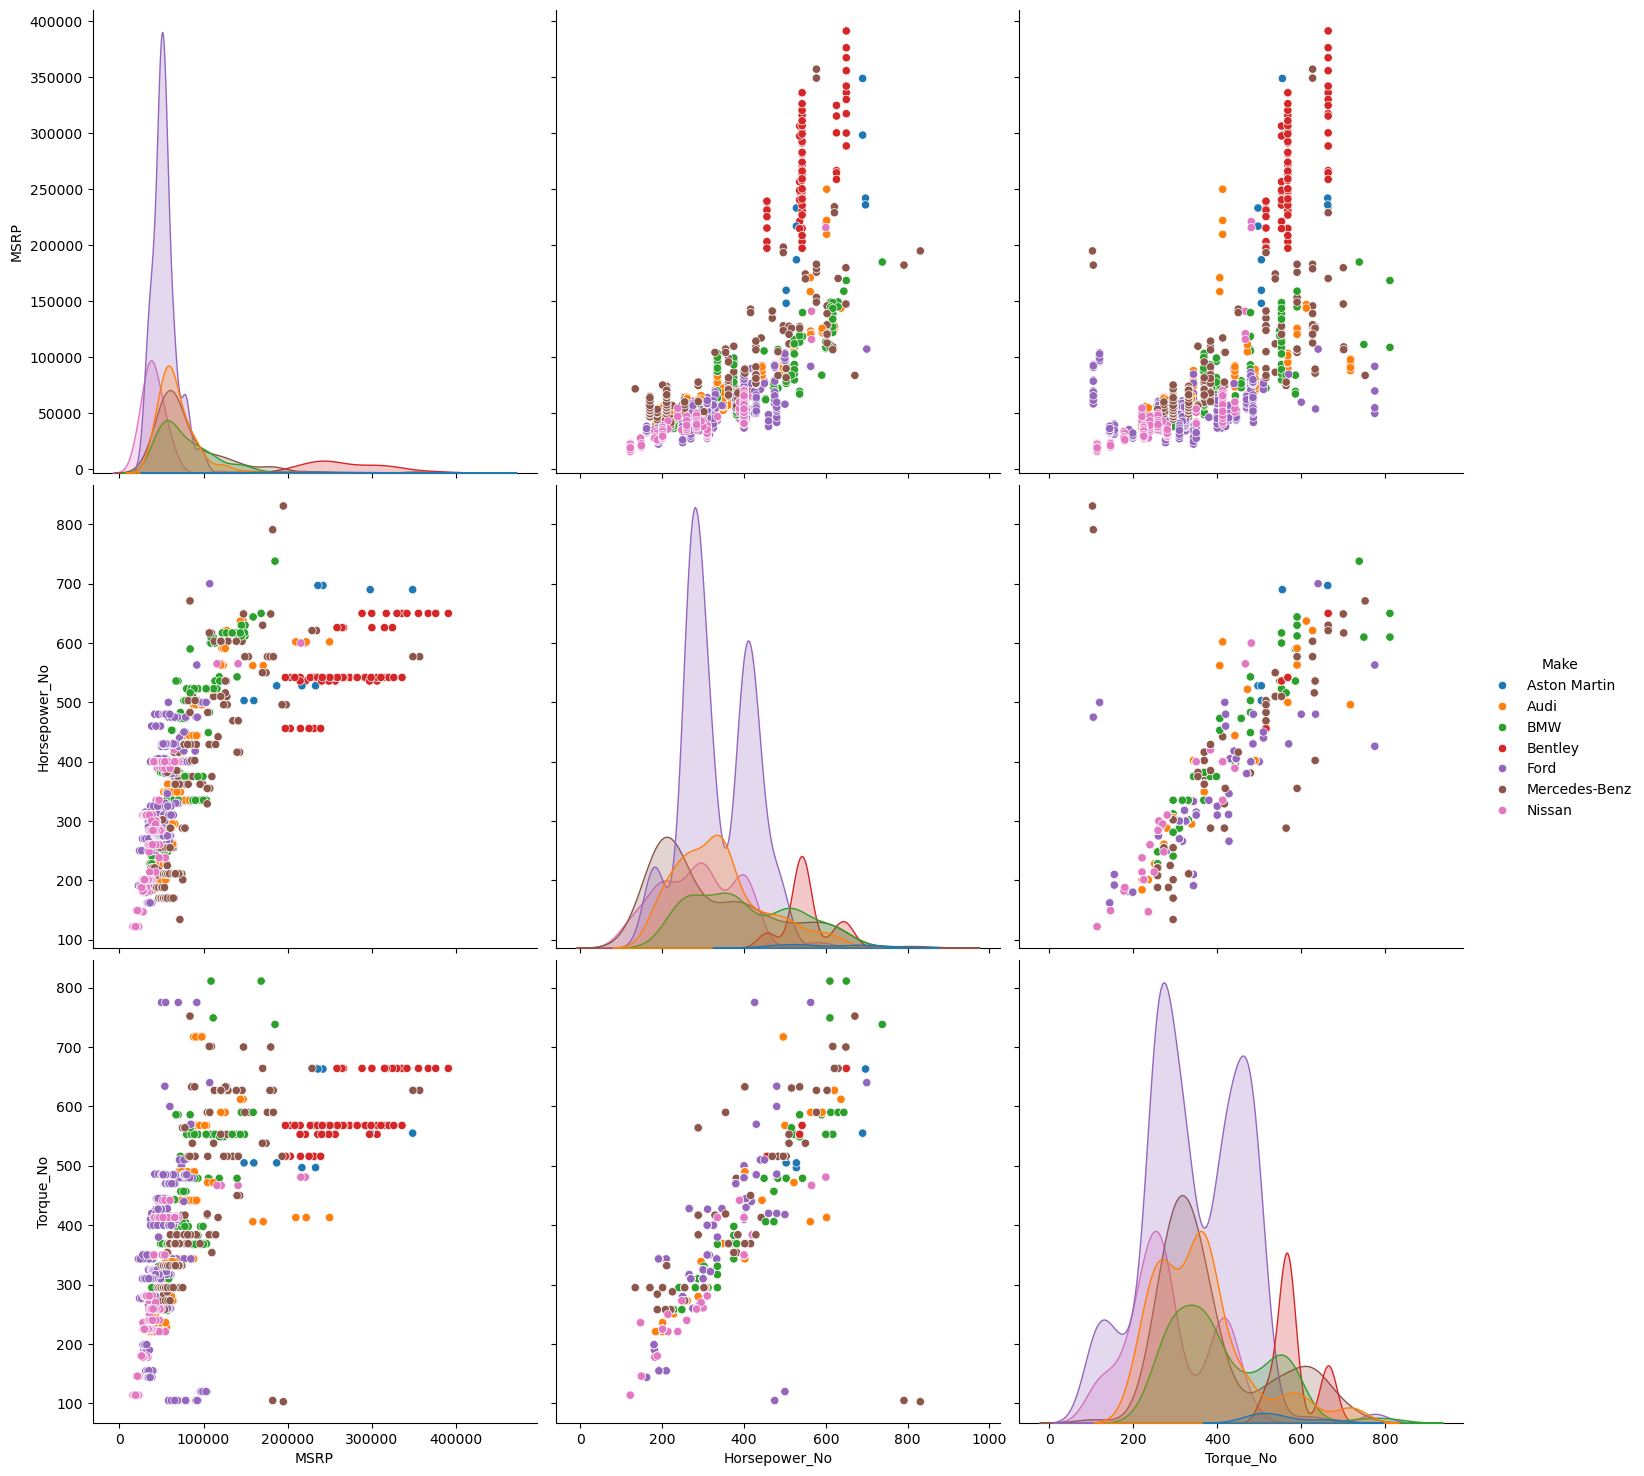

In [48]:
sns.pairplot(car_data[['MSRP','Horsepower_No','Torque_No','Make']],hue='Make',height=5)
plt.show()

In [49]:
categories=['Make','Body Size','Body Style', 'Engine Aspiration', 'Drivetrain','Transmission']


In [50]:
sns.set(rc={'figure.figsize':(14,5)})

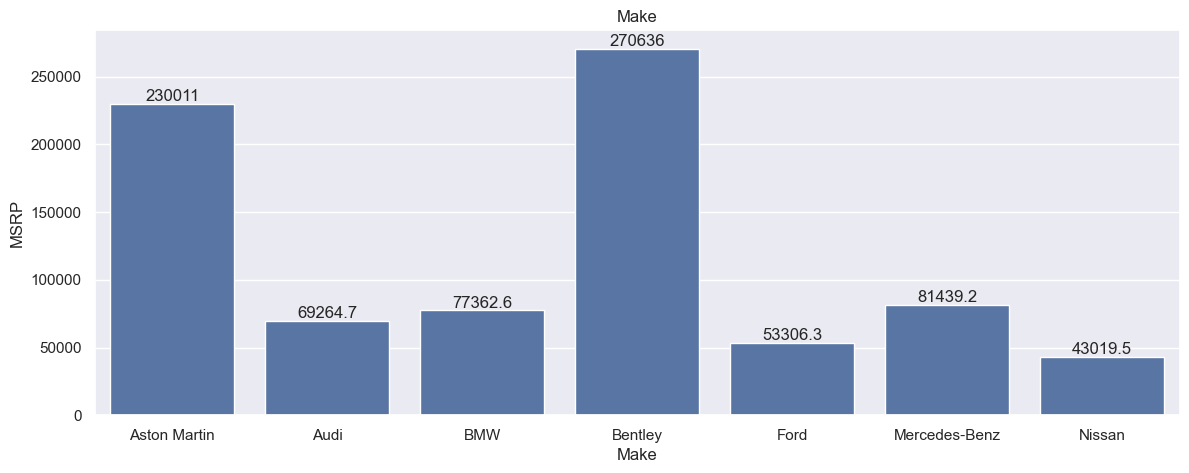

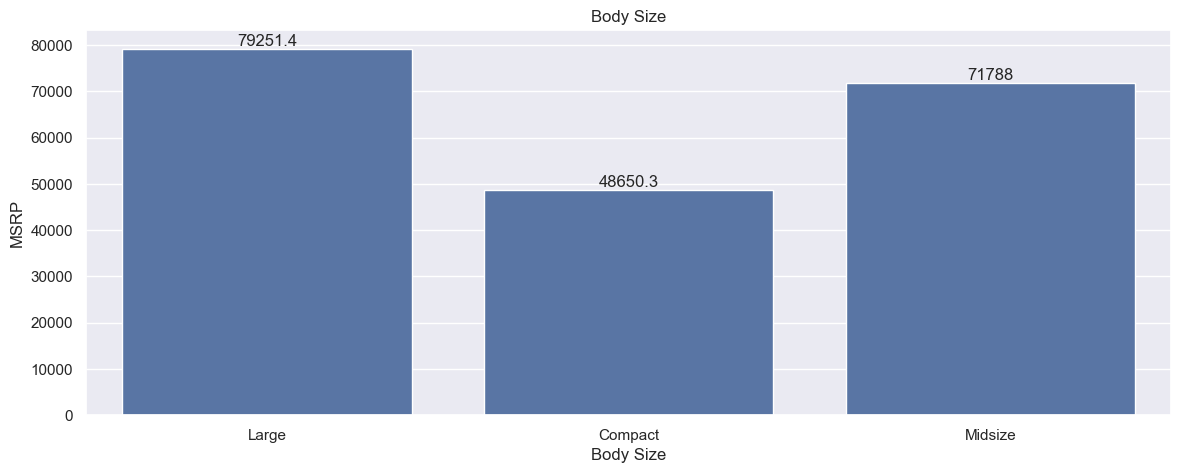

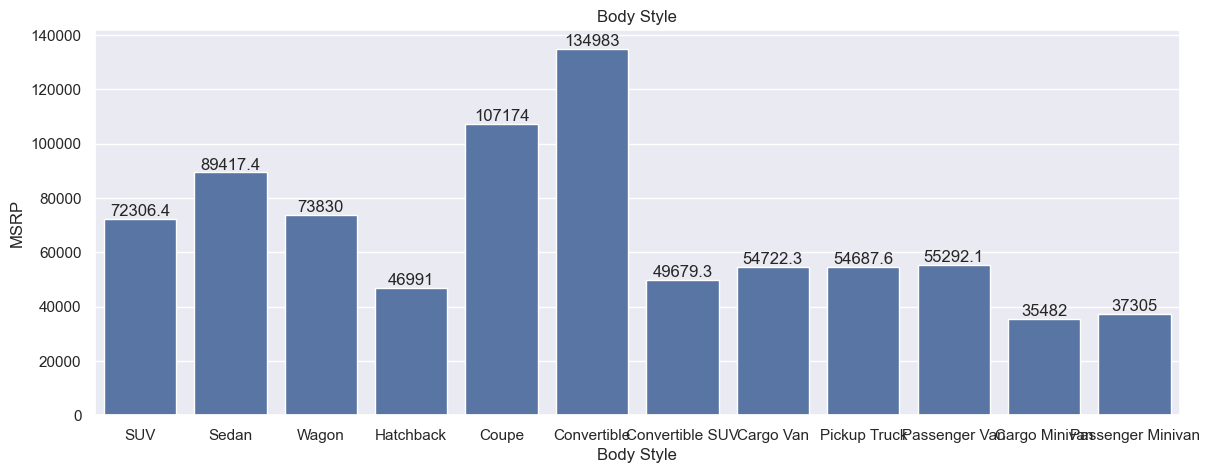

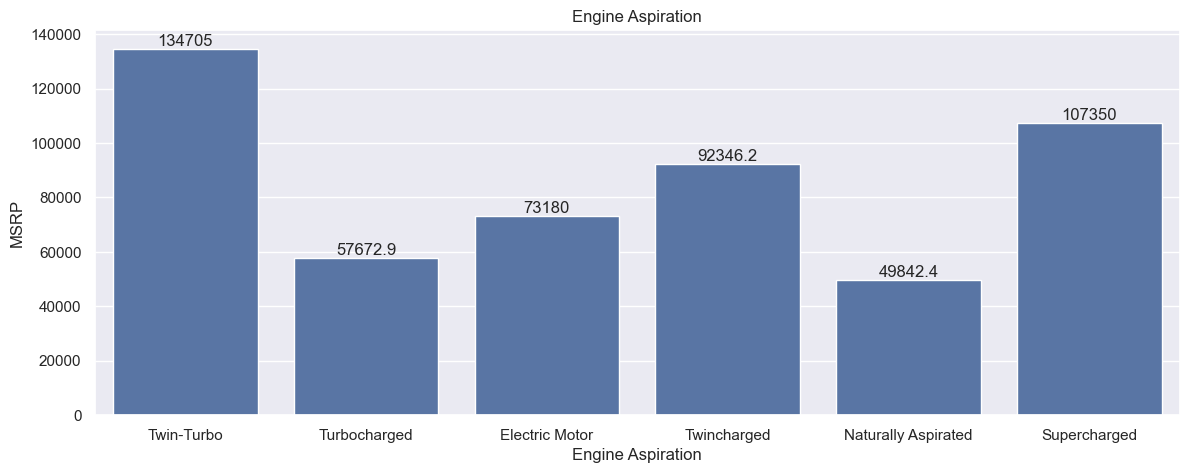

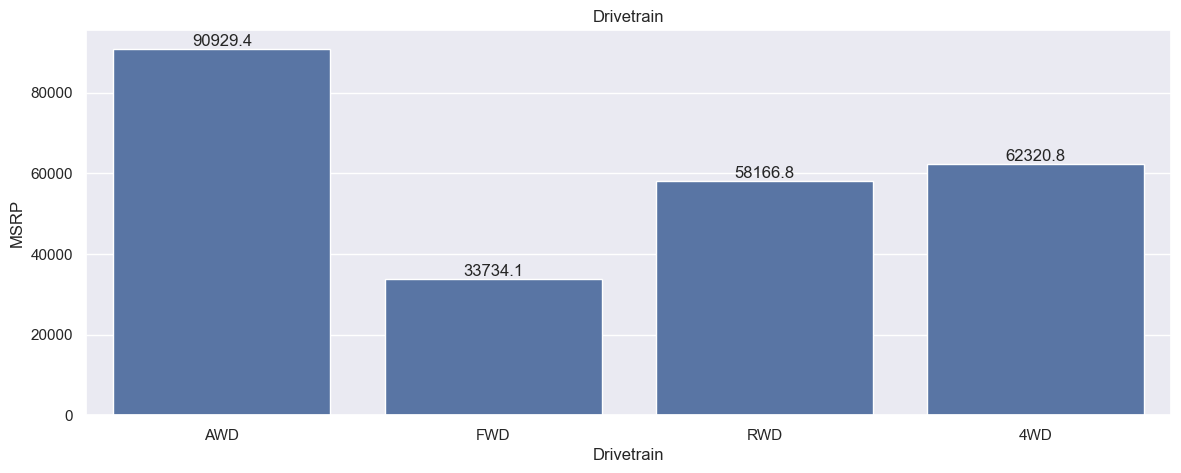

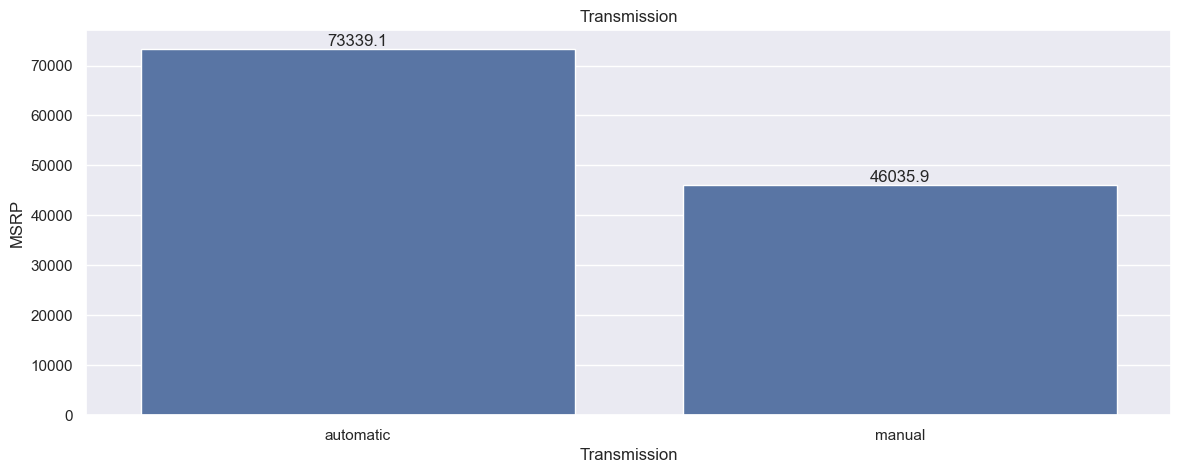

In [51]:
for c in categories:
    ax=sns.barplot(x=c,y="MSRP",data=car_data,errorbar=('ci',False))
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(c)
    plt.show()

In [52]:
n_categories=['MSRP','Used/New Price','Horsepower_No','Torque_No']


In [53]:
sns.set(rc={'figure.figsize':(10,5)})


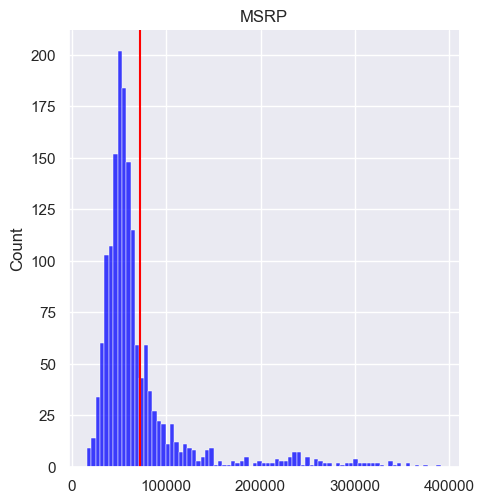

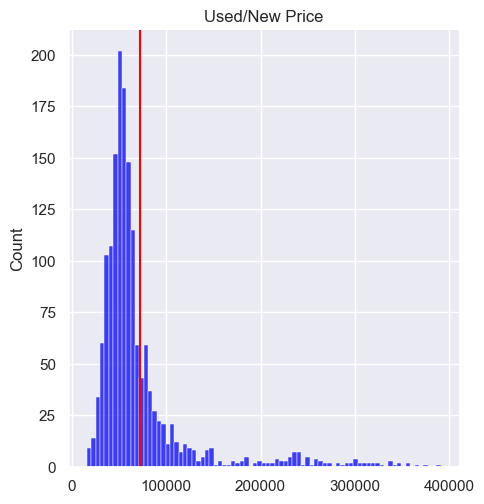

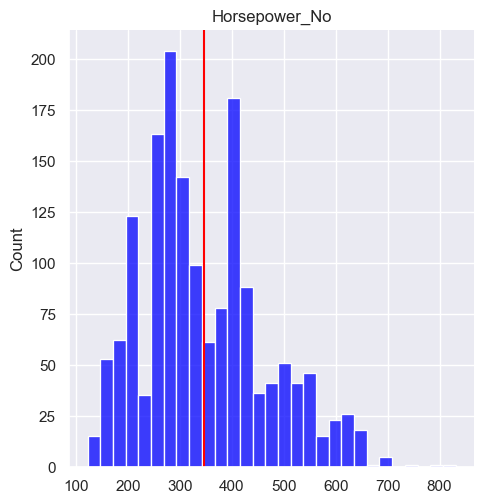

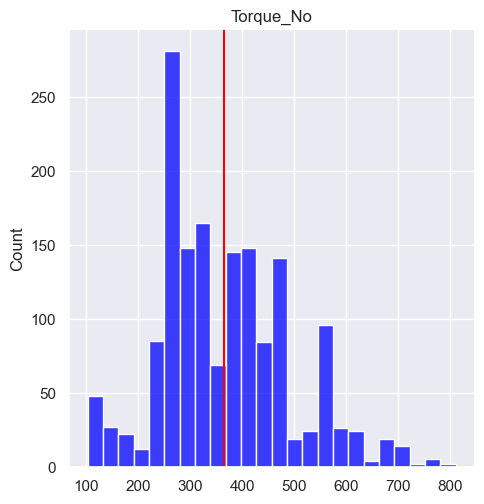

In [54]:
for n in n_categories:
    x=car_data[n].values
    sns.displot(x,color='blue')
    mean=car_data[n].mean()
    plt.axvline(x=mean,ymin=0,ymax=1,color='red')
    plt.title(n)
    plt.show()

the median of  MSRP is:  55945.0


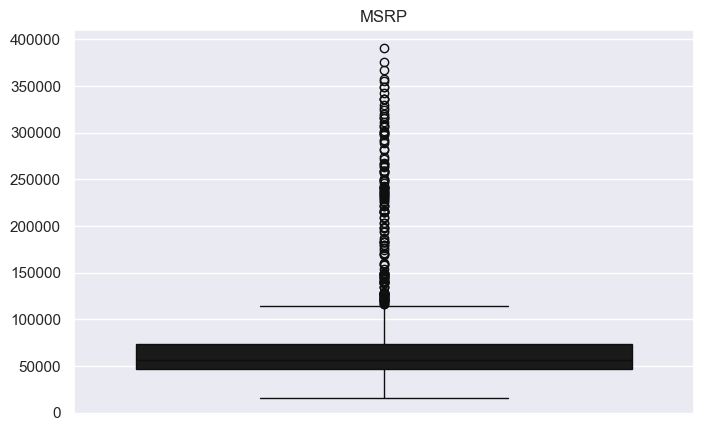

the median of  Used/New Price is:  55945.0


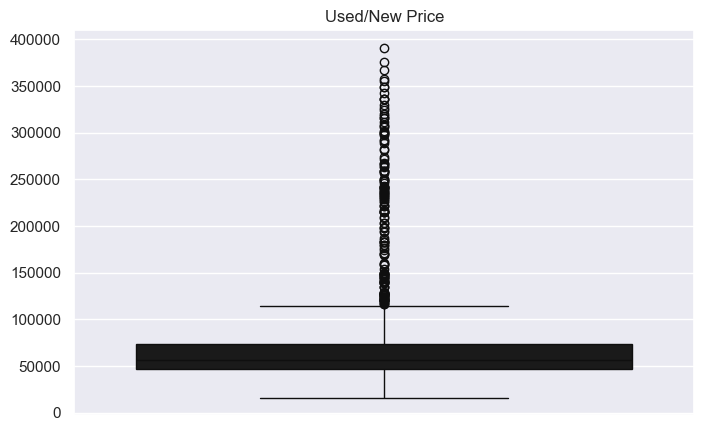

the median of  Horsepower_No is:  325.0


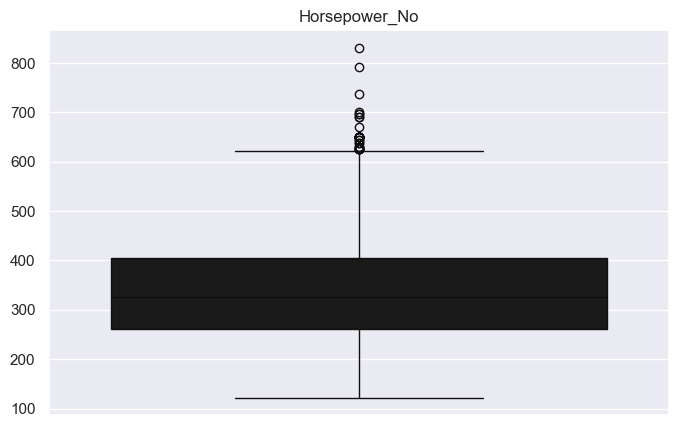

the median of  Torque_No is:  343.3888888888889


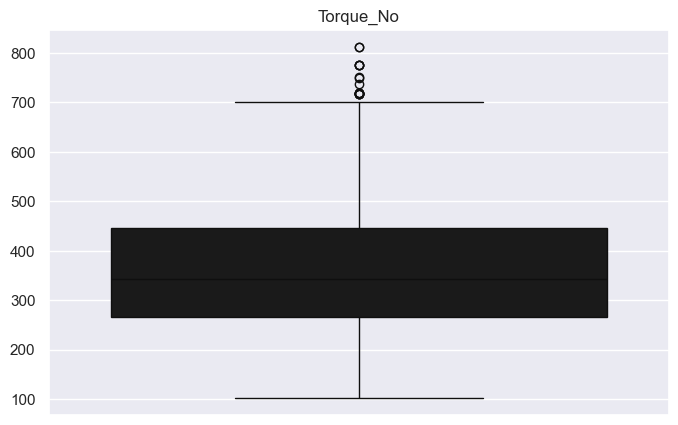

In [55]:
sns.set(rc={'figure.figsize':(8,5)})
for c in n_categories:
    x=car_data[c].values
    sns.boxplot(x,color='k')
    print('the median of ',c,'is: ',car_data[c].median())
    plt.title(c)
    plt.show()

In [56]:
categories = ['Make','Body Size','Body Style', 'Engine Aspiration', 'Drivetrain','Transmission']

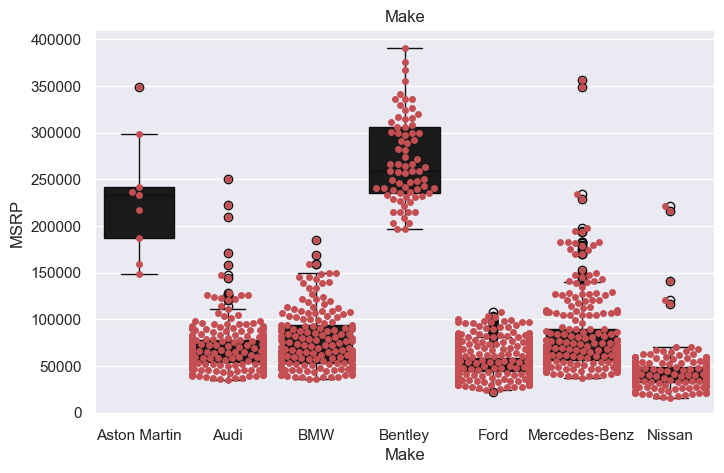

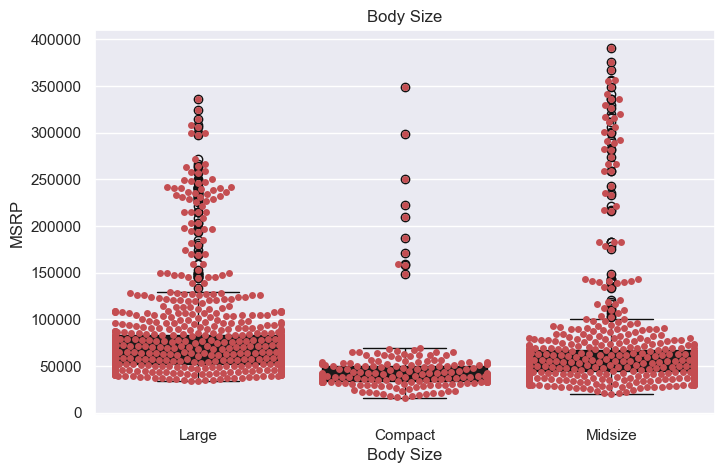

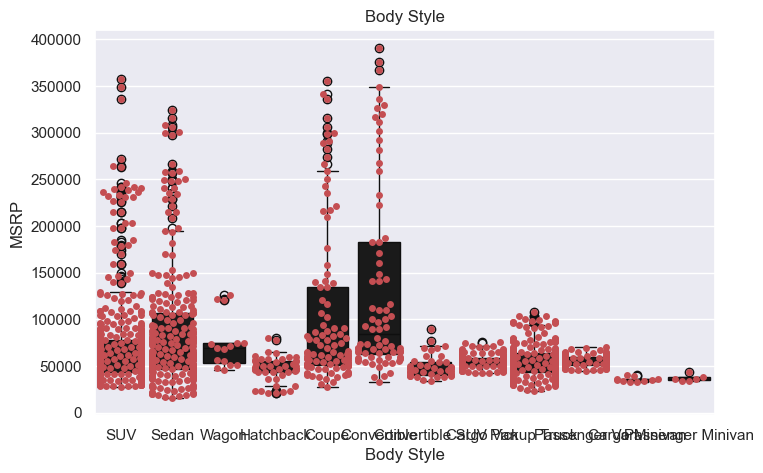

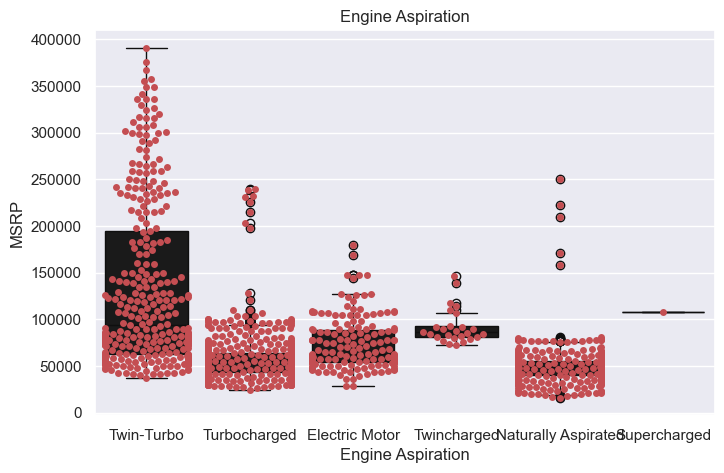

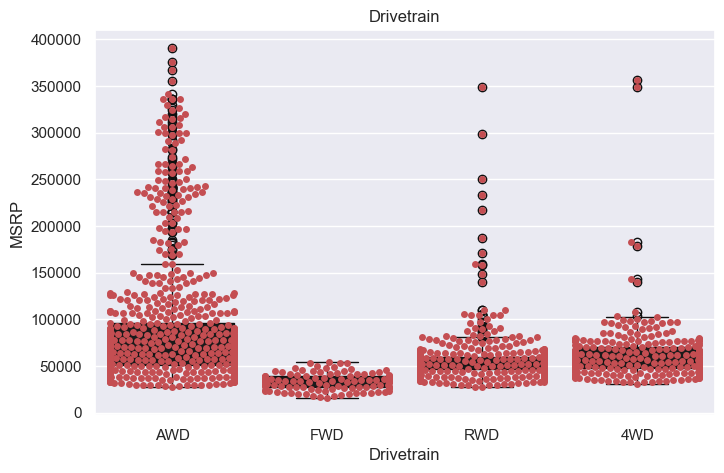

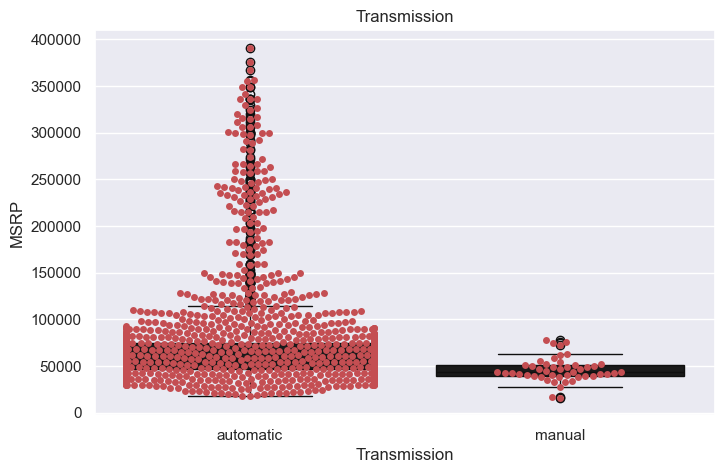

In [57]:
import warnings
warnings.filterwarnings('ignore')
sns.set(rc={'figure.figsize':(8,5)})
for c in categories:
    sns.boxplot(x=c,y='MSRP',data=car_data,color='k')
    sns.swarmplot(x=c,y='MSRP',data=car_data,color='r')
    plt.title(c)
    plt.show()

In [58]:
new_car_data=car_data.drop(['index','Model','Year', 'Trim', 'Used/New Price', 'Horsepower', 'Torque'], axis=1)

In [59]:
new_car_data=pd.get_dummies(new_car_data,columns=['Make','Body Size','Body Style', 'Engine Aspiration', 'Drivetrain','Transmission'],dtype=int)
display(new_car_data)

,MSRP,Horsepower_No,Torque_No,Make_Aston Martin,Make_Audi,Make_BMW,Make_Bentley,Make_Ford,Make_Mercedes-Benz,Make_Nissan,...,Engine Aspiration_Supercharged,Engine Aspiration_Turbocharged,Engine Aspiration_Twin-Turbo,Engine Aspiration_Twincharged,Drivetrain_4WD,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD,Transmission_automatic,Transmission_manual
0,242000.0,697.0,663.0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,0
1,35800.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
2,37800.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
3,41400.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,39400.0,201.0,221.0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,50990.0,400.0,350.0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
1606,53990.0,400.0,350.0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
1607,53990.0,400.0,350.0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,1
1608,40990.0,400.0,350.0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,1


In [60]:
n_variables=['MSRP','Horsepower_No','Torque_No']
pc=new_car_data[n_variables].corr(method='pearson')
print(pc)

                   MSRP  Horsepower_No  Torque_No
MSRP           1.000000       0.703226   0.620679
Horsepower_No  0.703226       1.000000   0.786370
Torque_No      0.620679       0.786370   1.000000


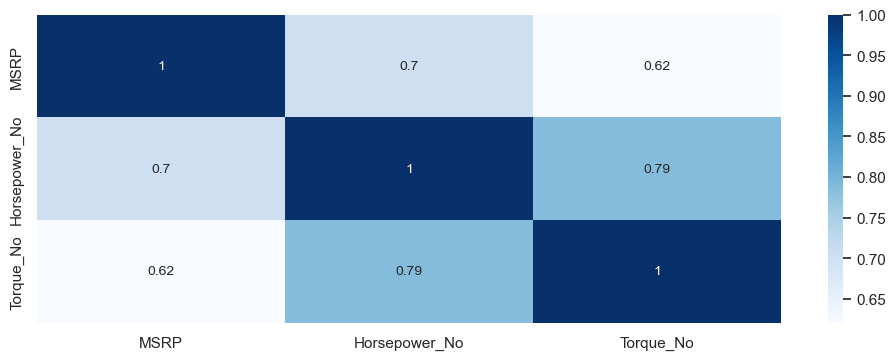

In [61]:
sns.set(rc={'figure.figsize':(12,4)})
cols=n_variables
ax=sns.heatmap(pc,annot=True,yticklabels=cols,xticklabels=cols,annot_kws={'size':10},cmap='Blues')

In [64]:
x=new_car_data.drop(['MSRP'],axis=1).values
print(x.shape)

(1610, 36)


In [65]:
y=new_car_data['MSRP'].astype(int)
print(y.shape)

(1610,)


In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=15)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1288, 36)
(322, 36)
(1288,)
(322,)


In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,explained_variance_score,mean_absolute_error,mean_squared_error
lr=LinearRegression(fit_intercept=True)
model=lr.fit(x_train,y_train)
y_pred=lr.predict(x_train)
y_final_predict=lr.predict(x)
print(y_pred)


[122518.67687727  28613.09278888  52612.80128808 ...  65411.18128556
  38133.6001676   52778.05656344]


In [88]:
print('The Accuracy  on the training dataset is: ', lr.score(x_train, y_train) )
print('The Accuracy r2  on the training dataset prediction is: ', r2_score(y_train,y_pred) )   

print("")

print('The Accuracy  on the testing dataset is: ', lr.score(x_test, y_test) )

print("")

print('The RMSE  on the training dataset is: ',sqrt(mean_squared_error(y_train,y_pred)))
print('The RMSE  on the testing dataset is: ',sqrt(mean_squared_error(y_test,lr.predict(x_test))))

print("")

print('The MAE  on the training dataset is: ',mean_absolute_error(y_train,y_pred))
print('The MAE  on the testing dataset is: ',mean_absolute_error(y_test,lr.predict(x_test)))


print("")

print('Coefficients: ', lr.coef_ )

print("")

print('Intercept: ', lr.intercept_)

The Accuracy  on the training dataset is:  0.8958051322153382
The Accuracy r2  on the training dataset prediction is:  0.8958051322153382

The Accuracy  on the testing dataset is:  0.919869347062912

The RMSE  on the training dataset is:  17419.60946983816
The RMSE  on the testing dataset is:  16533.89130765332

The MAE  on the training dataset is:  10597.643446612077
The MAE  on the testing dataset is:  11088.087358398148

Coefficients:  [ 2.23029786e+02 -1.93898826e+01  5.55922954e+04 -2.91252108e+04
 -3.66030124e+04  1.16241618e+05 -4.44002181e+04 -1.62430999e+04
 -4.54623719e+04  8.71327761e+01 -1.76476081e+02  8.93433044e+01
  6.04616426e+02  8.14988521e+03  1.42364450e+04  1.35515264e+02
  6.36205381e+02 -4.40434387e+03  6.17331163e+03  8.26163379e+03
 -1.77964511e+04 -5.16057655e+03 -3.71100754e+03 -7.12523364e+03
  6.28458603e+03  1.80043235e+03 -1.34733595e+04 -2.58974594e+02
  1.07720399e+04 -5.12472422e+03  4.85266205e+03 -3.37289118e+03
  4.30689194e+03 -5.78666281e+03  1.0

In [74]:
#pickle file deployment
pickle.dump(lr,open('linear_model.pkl','wb'))
model=pickle.load(open('linear_model.pkl','rb'))
print(model.predict(x_test))

[ 62568.38468465  59054.20543954  69785.39439673  59907.0375491
  70749.71716686  41973.47642644  17815.97490394  52925.07109076
  61204.85215096 281127.56415738  31857.47946399  48414.8805779
  50623.04804479  60611.03192836  50511.2994643   96989.33278599
  43861.9961316   59728.22113916  71404.47610093  69118.56516178
  61316.60073145  52512.23717852  53036.81967125  20684.52196453
  23653.77838888  53302.63905618  67368.91739148  20684.52196453
  72770.86725007 149534.96563499  18211.30310524  38452.78535496
  69118.56516178  17815.97490394  49721.54357171  71632.67724661
  64098.49965382  53036.81967125  41928.55484036  52925.07109076
  20933.30967232  27813.46049332  60174.52888652  71321.29823761
  86041.16653404  46273.55722975  60939.03276603  31323.84682616
  65411.18128556  76158.0223559   18211.30310524  38795.38876518
  66635.68020641  50623.04804479  50511.2994643   58425.12664979
  59054.20543954  20933.30967232  53036.81967125  65411.18128556
  23404.89411547  38795.388